# Problem Statement 5 :-->
A certain university wants to understand the relationship between students’ SAT scores and their GPA. Build a Simple Linear Regression model with GPA as the target variable and record the RMSE and correlation coefficient values for different models.

# Business Objectives:-->
Understand the relationship between SAT scores and GPA to analyze academic performance.

Develop a predictive model to estimate GPA based on SAT scores.

Provide insights for university admissions and student performance evaluation.

# Constraints:-->
The model should be interpretable and easy to explain to educational administrators.

The relationship may not be strictly linear, requiring transformations for better accuracy.

In [1]:
#import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
#load the dataset
df = pd.read_csv("SAT_GPA.csv") 

In [3]:
#perform Exploratory data analysis
df.head(5)

,SAT_Scores,GPA
0,206,2.3
1,214,2.4
2,717,3.5
3,580,2.8
4,404,2.6


In [4]:
#information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SAT_Scores  200 non-null    int64  
 1   GPA         200 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.2 KB


In [5]:
#shape of dataset
df.shape

(200, 2)

In [6]:
#description of dataset
df.describe()

,SAT_Scores,GPA
count,200.000000,200.000000
mean,491.810000,2.849500
std,174.893834,0.541076
min,202.000000,2.000000
25%,349.750000,2.400000
50%,480.500000,2.800000
75%,641.500000,3.400000
max,797.000000,3.900000


In [7]:
#rename the column names for ease of use
df.columns=["SAT_Score","GPA"]

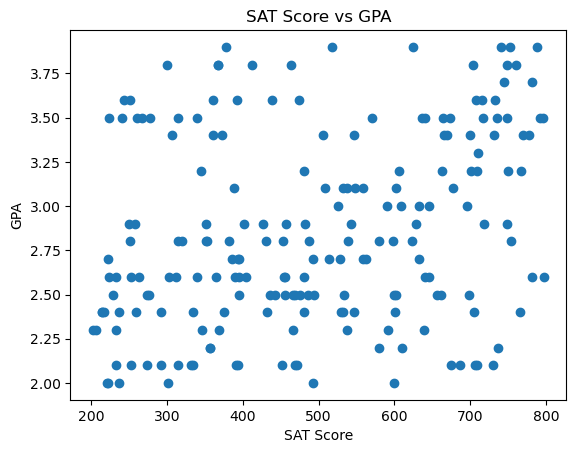

In [8]:
# Scatter plot of SAT vs GPA
plt.scatter(df["SAT_Score"], df["GPA"])
plt.xlabel("SAT Score")
plt.ylabel("GPA")
plt.title("SAT Score vs GPA")
plt.show()

In [9]:
# Apply Log Transformation before splitting
df["Log_SAT"] = np.log(df["SAT_Score"])

In [10]:
# Train-test split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [11]:
#model 1:  Simple Linear Regression Model
model1 = smf.ols('GPA ~ SAT_Score', data=train).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     18.03
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           3.70e-05
Time:                        13:59:23   Log-Likelihood:                -118.84
No. Observations:                 160   AIC:                             241.7
Df Residuals:                     158   BIC:                             247.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3789      0.120     19.752      0.0

In [12]:
# Predictions
train_pred1 = model1.predict(train)
test_pred1 = model1.predict(test)

In [13]:
# RMSE Calculation
train_rmse1 = np.sqrt(mean_squared_error(train["GPA"], train_pred1))
test_rmse1 = np.sqrt(mean_squared_error(test["GPA"], test_pred1))

In [14]:
# Correlation Coefficient
corr1 = np.corrcoef(df["SAT_Score"], df["GPA"])[0, 1]

In [15]:
#model 2: Log Transformation Model
df["Log_SAT"] = np.log(df["SAT_Score"])

In [16]:
model2 = smf.ols('GPA ~ Log_SAT', data=train).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     15.35
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           0.000133
Time:                        14:00:05   Log-Likelihood:                -120.07
No. Observations:                 160   AIC:                             244.1
Df Residuals:                     158   BIC:                             250.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3331      0.646      0.515      0.6

In [17]:
train_pred2 = model2.predict(train)
test_pred2 = model2.predict(test)

In [18]:
train_rmse2 = np.sqrt(mean_squared_error(train["GPA"], train_pred2))
test_rmse2 = np.sqrt(mean_squared_error(test["GPA"], test_pred2))

In [19]:
corr2 = np.corrcoef(df["Log_SAT"], df["GPA"])[0, 1]

In [20]:
#model 3:  Polynomial Regression
model3 = smf.ols('GPA ~ SAT_Score + I(SAT_Score**2)', data=train).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.108
Method:                 Least Squares   F-statistic:                     10.66
Date:                Mon, 03 Mar 2025   Prob (F-statistic):           4.55e-05
Time:                        14:00:39   Log-Likelihood:                -117.30
No. Observations:                 160   AIC:                             240.6
Df Residuals:                     157   BIC:                             249.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             2.9329      0.33

In [21]:
train_pred3 = model3.predict(train)
test_pred3 = model3.predict(test)

In [22]:
train_rmse3 = np.sqrt(mean_squared_error(train["GPA"], train_pred3))
test_rmse3 = np.sqrt(mean_squared_error(test["GPA"], test_pred3))

In [23]:
corr3 = np.corrcoef(df["SAT_Score"], df["GPA"])[0, 1]

In [24]:
# Print RMSE and Correlation Values
print(f"--- RMSE Comparison ---")
print(f"Simple Linear Regression RMSE: {test_rmse1}")
print(f"Log Transformation RMSE: {test_rmse2}")
print(f"Polynomial Regression RMSE: {test_rmse3}")

--- RMSE Comparison ---
Simple Linear Regression RMSE: 0.5474753672893549
Log Transformation RMSE: 0.5440367189724865
Polynomial Regression RMSE: 0.5520338468770222


In [25]:
print(f"--- Correlation Coefficient Comparison ---")
print(f"Simple Linear Regression: {corr1}")
print(f"Log Transformation: {corr2}")
print(f"Polynomial Regression: {corr3}")

--- Correlation Coefficient Comparison ---
Simple Linear Regression: 0.2935382754761456
Log Transformation: 0.2777197617677403
Polynomial Regression: 0.2935382754761456


Observations:

1. Simple Linear Regression

RMSE: 0.5475 (higher compared to log transformation).
Correlation Coefficient: 0.2935 (weak positive correlation).
The low correlation suggests that SAT scores alone do not strongly predict GPA.

2. Log Transformation Model

RMSE: 0.5440 (slightly lower than Simple Linear Regression, showing minor improvement).
Correlation Coefficient: 0.2777 (slightly lower than simple regression).
This indicates that log transformation does not significantly improve model performance.

3. Polynomial Regression

RMSE: 0.5520 (slightly worse than other models).
Correlation Coefficient: 0.2935 (same as simple regression).
The polynomial model did not improve correlation or prediction accuracy, implying that a nonlinear relationship does not significantly exist between SAT scores and GPA.

Since, all models have low correlation, meaning that SAT scores alone are not a strong predictor of GPA.
Log transformation did not provide significant improvemen.
Polynomial regression also failed to improve performance